In [7]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Unvaccinated children with starting point

In [24]:
with open('1_Scenario_results_with_initial_conditions.json') as json_file:
    F_results = json.load(json_file)


In [25]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [26]:
grouped_results

{'S[': [{'S[Rubella,7,8]': 0.0},
  {'S[PCV,0,2]': 1608000.0},
  {'S[Pertussis,10,1]': 0.0},
  {'S[Diphtheria,3,6]': 0.0},
  {'S[Mumps,4,7]': 0.0},
  {'S[Hib,8,1]': 0.0},
  {'S[Mumps,2,8]': 0.0},
  {'S[Diphtheria,2,10]': 0.0},
  {'S[HPV,3,2]': 0.0},
  {'S[Pertussis,4,5]': 0.0},
  {'S[Rotavirus,4,3]': 0.0},
  {'S[Measles,7,8]': 0.0},
  {'S[Measles,4,8]': 0.0},
  {'S[Tetanus,6,6]': 0.0},
  {'S[PCV,7,6]': 0.0},
  {'S[Polio,0,4]': 5222000.0},
  {'S[HPV,5,9]': 0.0},
  {'S[Pertussis,3,1]': 0.0},
  {'S[HPV,0,5]': 1900000.0},
  {'S[Measles,10,9]': 0.0},
  {'S[Hepatitis_B,3,10]': 0.0},
  {'S[PCV,2,9]': 129203210.61600849},
  {'S[Pertussis,2,4]': 0.0},
  {'S[Rotavirus,6,6]': 0.0},
  {'S[Measles,0,5]': 37210000.0},
  {'S[HPV,8,10]': 0.0},
  {'S[Mumps,7,4]': 0.0},
  {'S[Pertussis,5,5]': 0.0},
  {'S[Hib,3,1]': 0.0},
  {'S[Diphtheria,6,3]': 0.0},
  {'S[Rubella,1,1]': 0.0},
  {'S[PCV,9,7]': 0.0},
  {'S[Rotavirus,0,7]': 14250000.0},
  {'S[Diphtheria,7,10]': 0.0},
  {'S[HPV,7,6]': 0.0},
  {'S[Tetanus,3,

In [27]:
# Extracting data into lists
antigen_list = []
year_list = []
value_list = []
scenario_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Splitting the key and extracting Antigen, Year, and Scenario
        parts = key.split(',')[0][2:], int(key.split(',')[1]), int(key.split(',')[2][:-1])
        
        # Appending values to lists
        antigen_list.append(parts[0])
        year_list.append(parts[1])
        scenario_list.append(parts[2])
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list,
    'Scenario': scenario_list
})

# Displaying the DataFrame
print(df)


          Antigen  Year         Value  Scenario
0         Rubella     7  0.000000e+00         8
1             PCV     0  1.608000e+06         2
2       Pertussis    10  0.000000e+00         1
3      Diphtheria     3  0.000000e+00         6
4           Mumps     4  0.000000e+00         7
...           ...   ...           ...       ...
1315      Measles     5  0.000000e+00         9
1316          PCV     2  1.292032e+08         1
1317  Hepatitis_B     1  0.000000e+00         6
1318  Hepatitis_B     4  0.000000e+00         1
1319        Polio     0  5.222000e+06        10

[1320 rows x 4 columns]


,Antigen,Year,Value,Scenario
0,Measles,0,37210000.0,1
16,Hepatitis_B,0,3123000.0,1
20,Mumps,0,2610000.0,1
32,Hib,0,2595000.0,1
41,HPV,0,1900000.0,1
61,Rotavirus,0,14250000.0,1
67,Tetanus,0,5777000.0,1
69,Diphtheria,0,5706000.0,1
79,Rubella,0,35730000.0,1
82,PCV,0,1608000.0,1


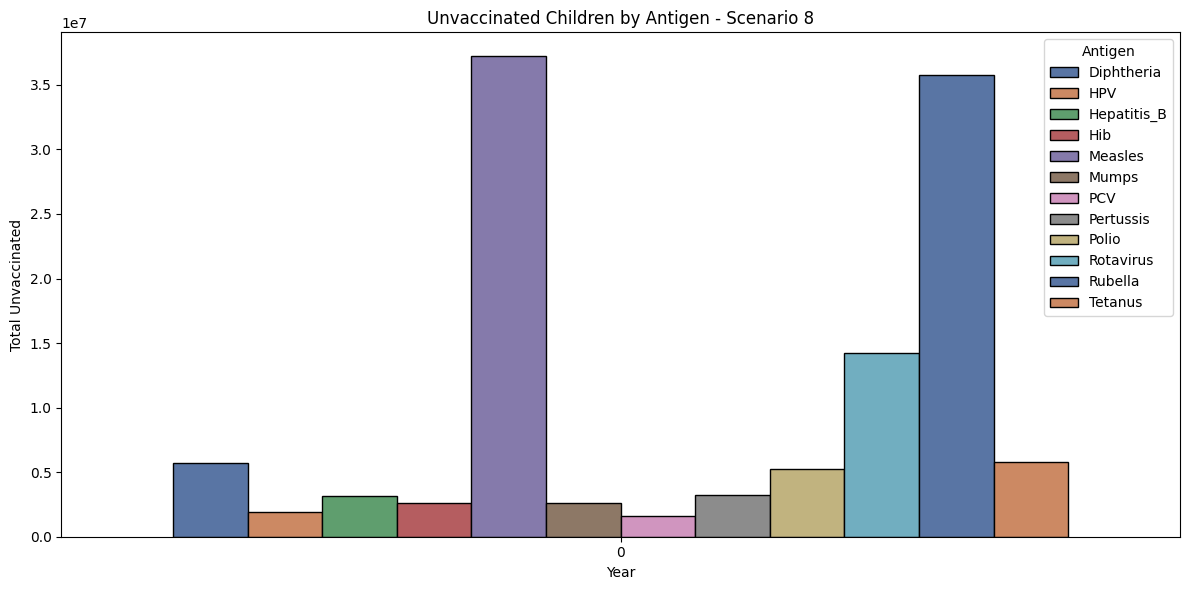

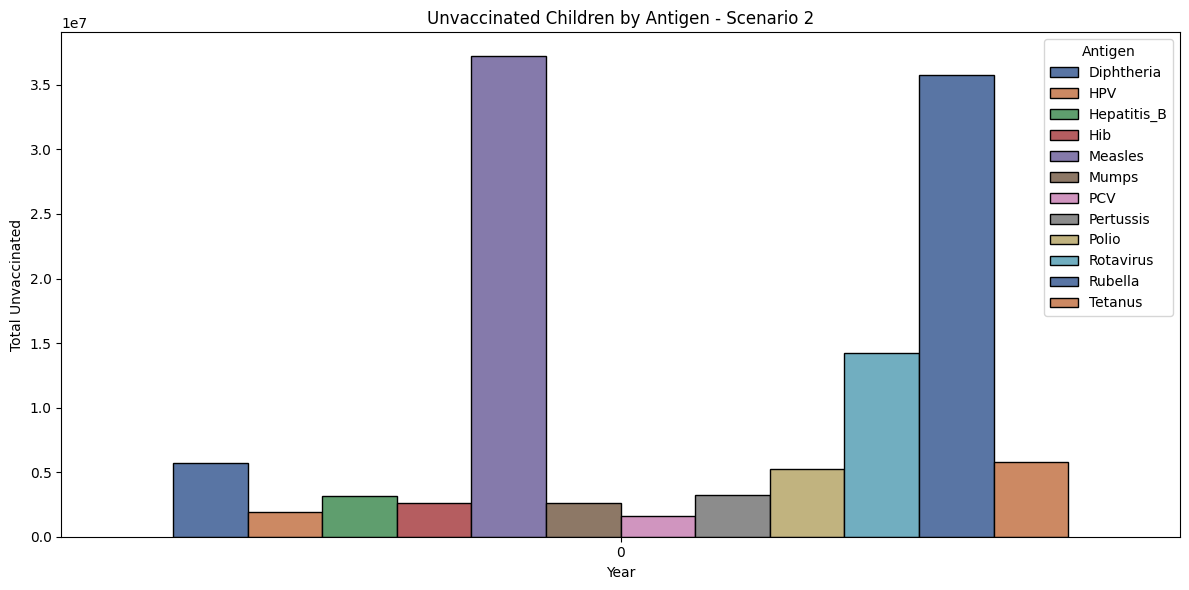

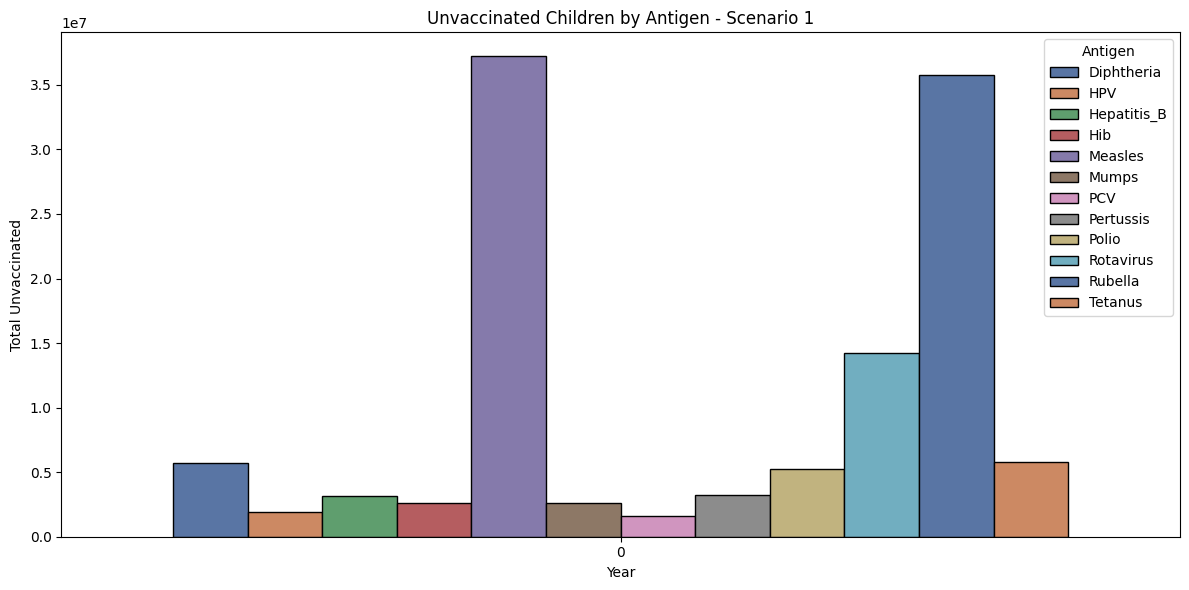

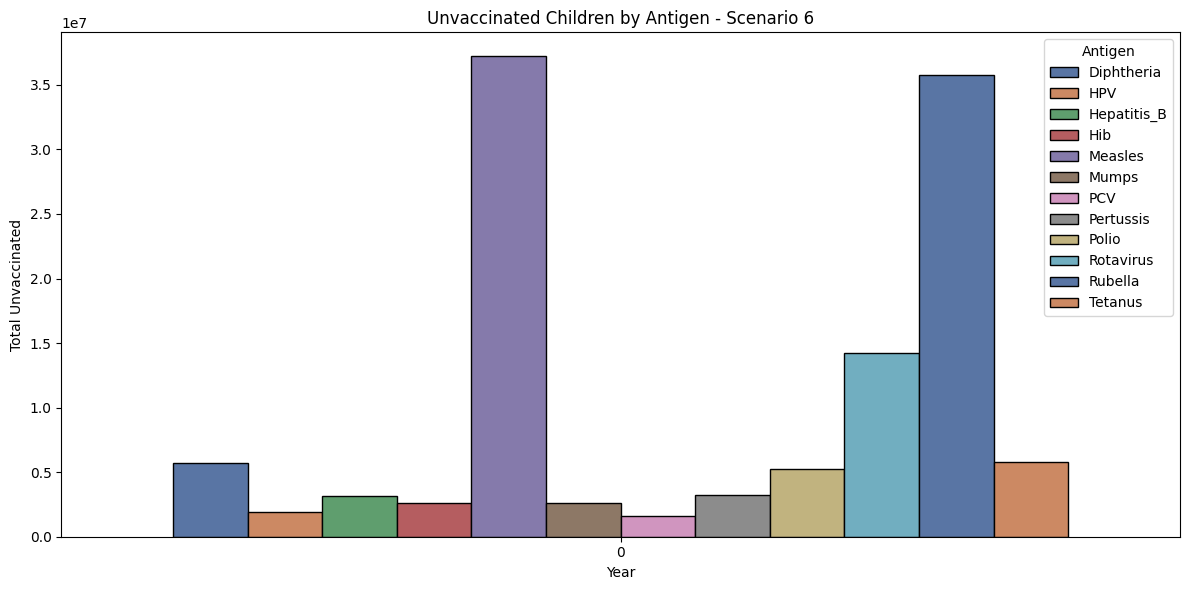

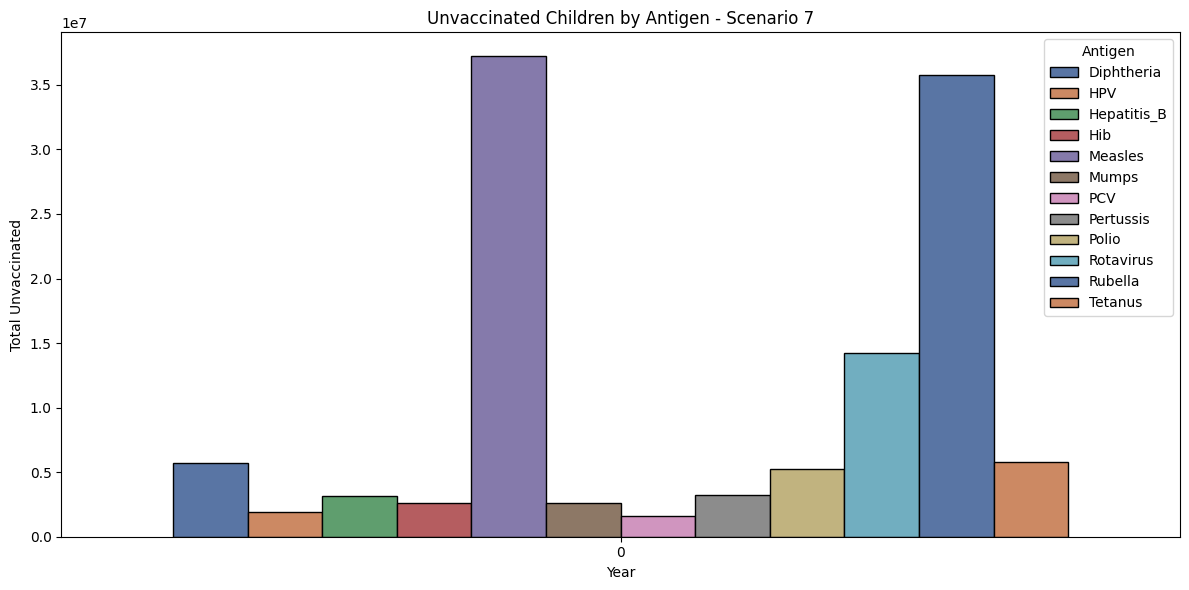

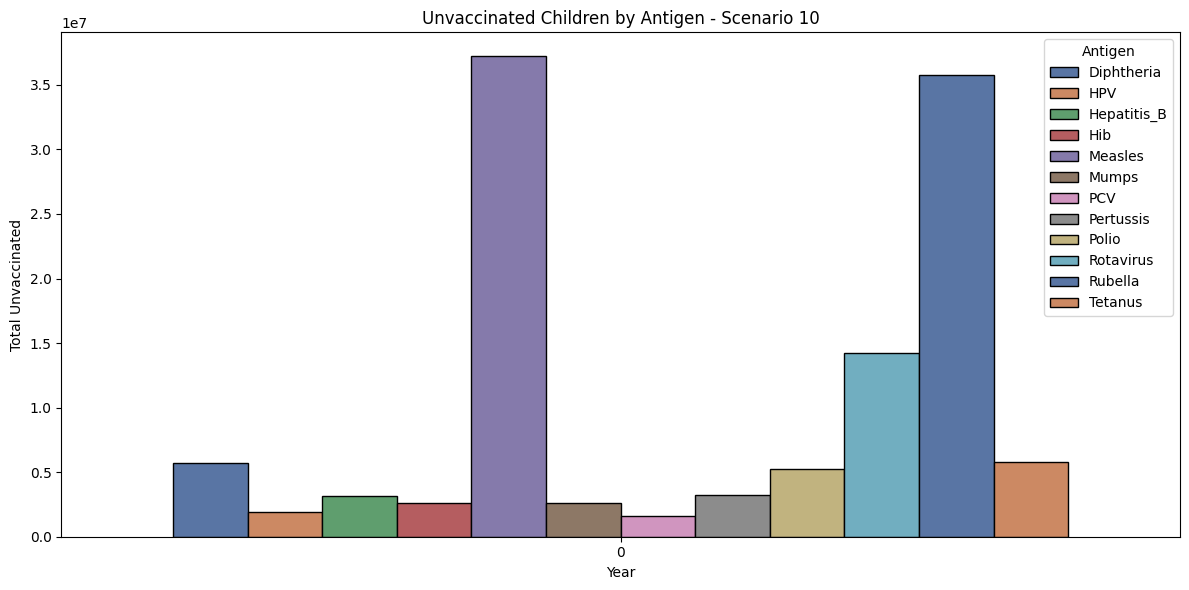

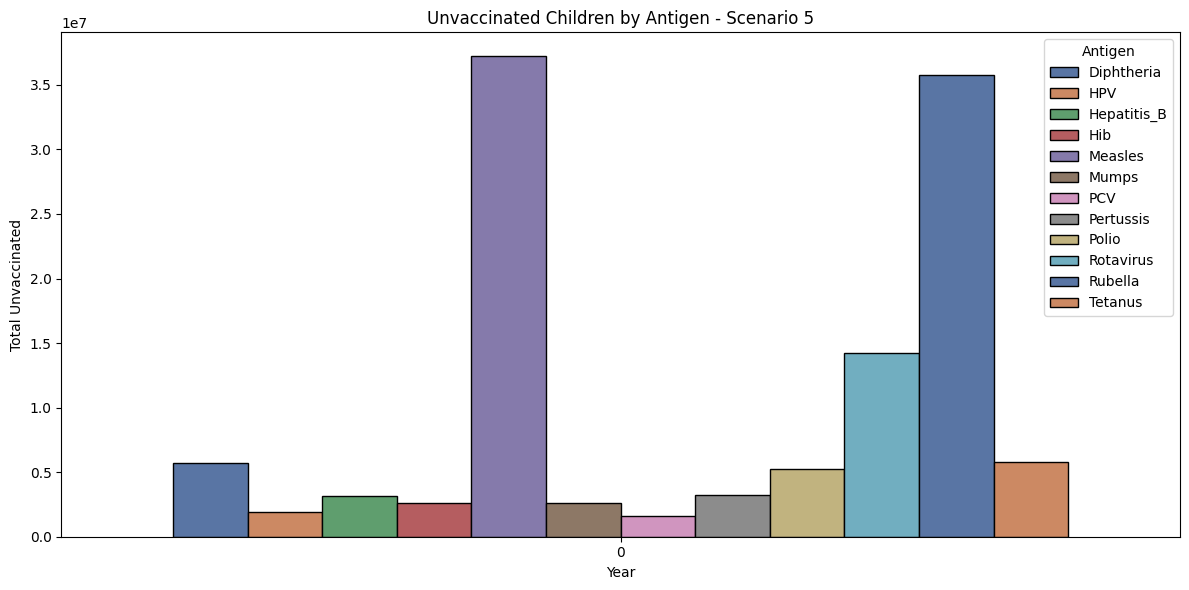

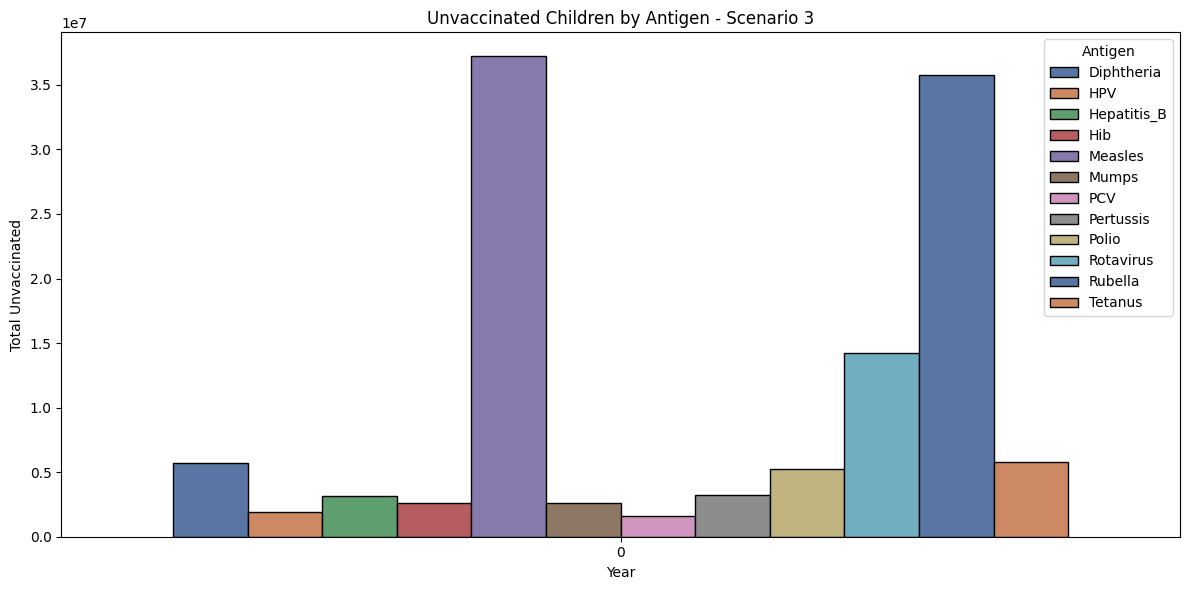

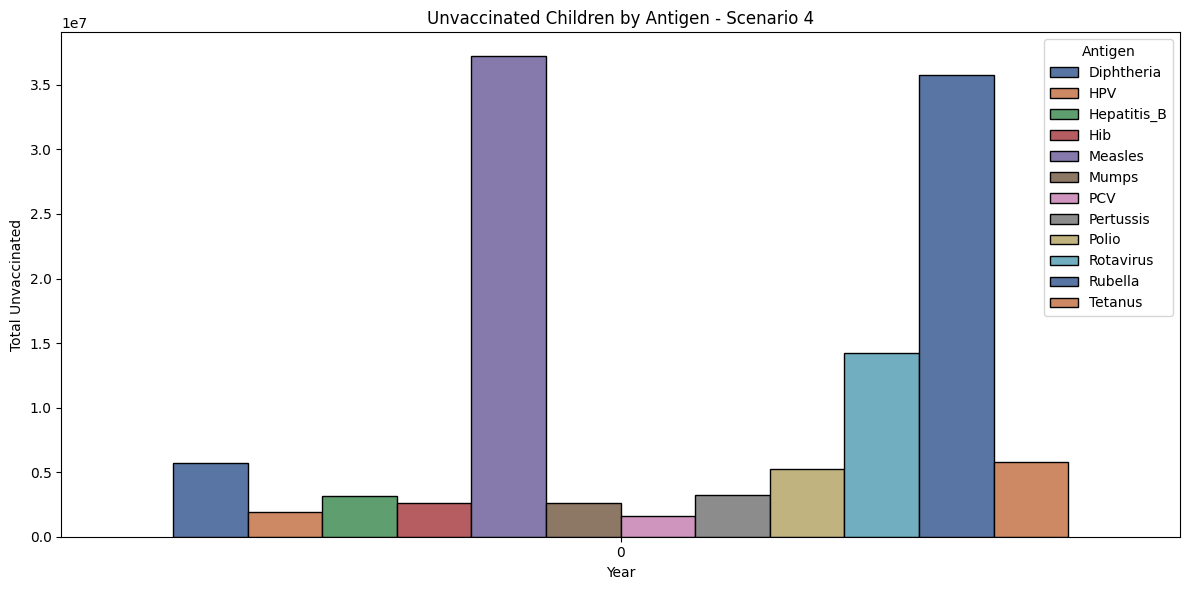

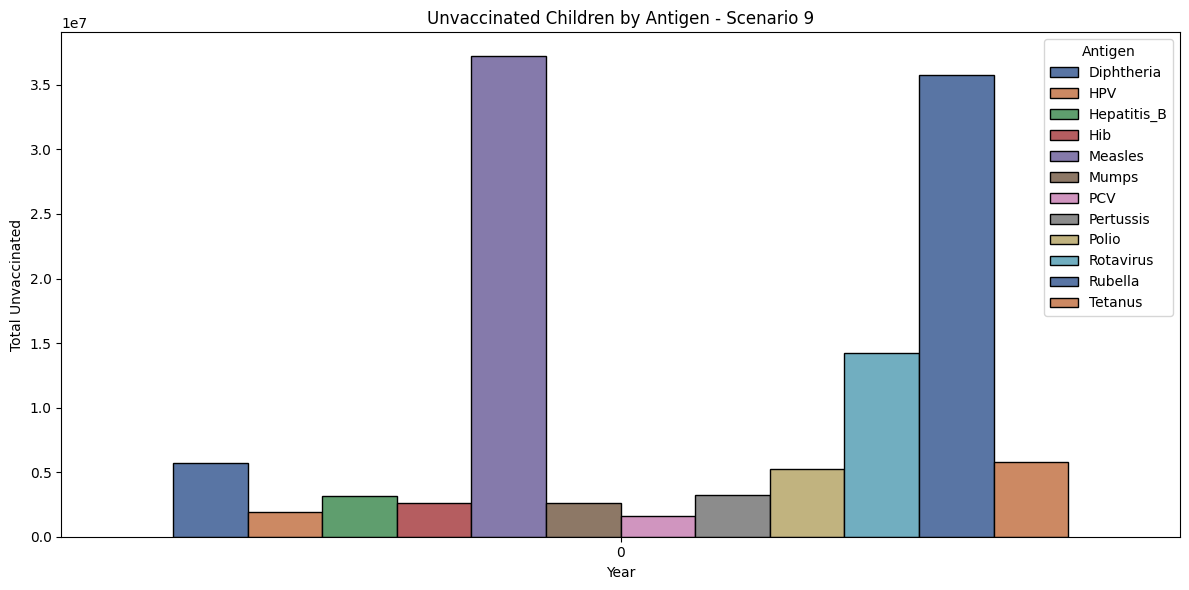

In [29]:
# iterates over all scenarios presented in the data
# Create a list of all years from 0 to 10
all_years = list(range(0, 11))

# Loop through each scenario and generate a separate plot
for scenario in df['Scenario'].unique():
    # Filter the DataFrame for the current scenario
    scenario_df = df[df['Scenario'] == scenario]

    # Grouping by Year and Antigen, and summing the Value column
    result = scenario_df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()
    result = result[result['Year'].between(0, 0)]

    # Filling missing combinations of Year and Antigen with 0.0 value
    result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

    # Melt the DataFrame to have a long format suitable for plotting
    result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

    # Set a color palette with distinct colors for each antigen
    palette = sns.color_palette("deep", n_colors=len(result['Antigen'].unique()))

    # Plotting the bar chart with seaborn
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Year', y='Value', hue='Antigen', data=result, palette=palette, edgecolor='black')  # Add edgecolor for boxes

    # Add vertical lines at each break between years (0 to 10)
    for year in all_years[1:]:
        plt.axvline(x=year - 0.5, color='gray', linestyle='--', linewidth=1)

    plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
    plt.ylim(0, df['Value'].max()+ (df['Value'].max()*0.05))
    plt.xlabel('Year')
    plt.ylabel('Total Unvaccinated')
    plt.title(f'Unvaccinated Children by Antigen - Scenario {scenario}')
    plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
    plt.tight_layout()  # Adjust layout for better visualization
    # plt.savefig(f'DeterministicEquivalent_MVP_unvax_{scenario}.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
    plt.show()
